# Calculating Important Numbers from Data Sets

In this notebook, we'll learn how to:
1. Calculate important statistical measures from datasets
2. Use various Python modules for data analysis
3. Create functions to predict outcomes based on data

In [21]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.linear_model import LinearRegression

# Set up matplotlib for better display
plt.style.use('seaborn-darkgrid')
%matplotlib inline

OSError: 'seaborn-darkgrid' is not a valid package style, path of style file, URL of style file, or library style name (library styles are listed in `style.available`)

## Creating a Small Dataset

Let's create a sample dataset representing student study hours and their corresponding scores.

In [ ]:
# Creating a small dataset
study_hours = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9])
exam_scores = np.array([55, 60, 65, 70, 75, 80, 85, 90, 95])

# Create a DataFrame
student_data = pd.DataFrame({
    'Hours': study_hours,
    'Scores': exam_scores
})

print("Sample Student Data:")
student_data

Sample Student Data:


,Hours,Scores
0,1,55
1,2,60
2,3,65
3,4,70
4,5,75
5,6,80
6,7,85
7,8,90
8,9,95


## Part 1: Calculating Important Statistical Measures

Let's calculate various statistical measures for our dataset.

In [ ]:
# Calculate important statistical measures
def calculate_statistics(data):
    # Calculate basic statistics
    mean = np.mean(data)
    median = np.median(data)
    std_dev = np.std(data)
    variance = np.var(data)
    minimum = np.min(data)
    maximum = np.max(data)
    
    # Calculate range
    data_range = maximum - minimum
    
    # Calculate quartiles
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1
    
    # Calculate skewness and kurtosis
    skewness = stats.skew(data)
    kurtosis = stats.kurtosis(data)
    
    # Return all statistics as a dictionary
    return {
        'Mean': mean,
        'Median': median,
        'Standard Deviation': std_dev,
        'Variance': variance,
        'Minimum': minimum,
        'Maximum': maximum,
        'Range': data_range,
        'Q1 (25%)': q1,
        'Q3 (75%)': q3,
        'IQR': iqr,
        'Skewness': skewness,
        'Kurtosis': kurtosis
    }

# Calculate statistics for study hours
hours_stats = calculate_statistics(study_hours)
print("\nStatistics for Study Hours:")
for stat, value in hours_stats.items():
    print(f"{stat}: {value:.4f}")

# Calculate statistics for exam scores
scores_stats = calculate_statistics(exam_scores)
print("\nStatistics for Exam Scores:")
for stat, value in scores_stats.items():
    print(f"{stat}: {value:.4f}")


Statistics for Study Hours:
Mean: 5.0000
Median: 5.0000
Standard Deviation: 2.5820
Variance: 6.6667
Minimum: 1.0000
Maximum: 9.0000
Range: 8.0000
Q1 (25%): 3.0000
Q3 (75%): 7.0000
IQR: 4.0000
Skewness: 0.0000
Kurtosis: -1.2300

Statistics for Exam Scores:
Mean: 75.0000
Median: 75.0000
Standard Deviation: 12.9099
Variance: 166.6667
Minimum: 55.0000
Maximum: 95.0000
Range: 40.0000
Q1 (25%): 65.0000
Q3 (75%): 85.0000
IQR: 20.0000
Skewness: 0.0000
Kurtosis: -1.2300


## Part 2: Data Visualization

Let's visualize our data to better understand the relationship between study hours and exam scores.

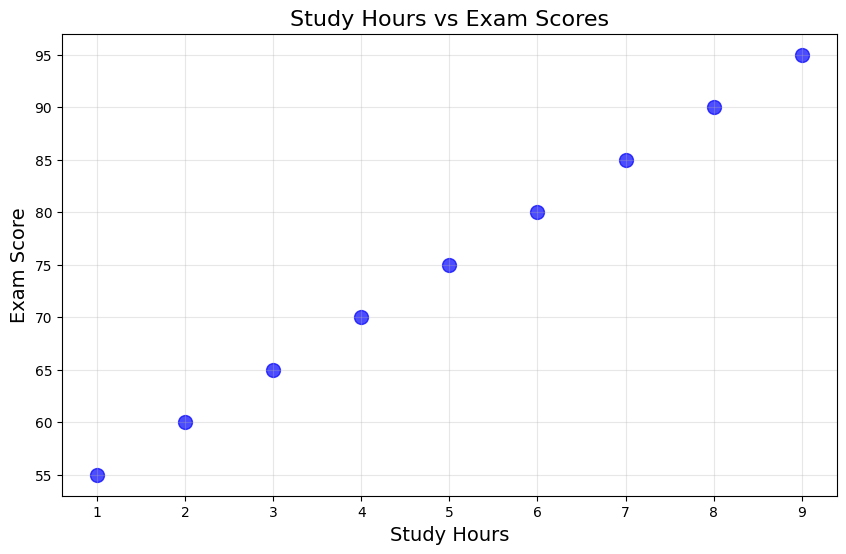

In [ ]:
# Create a scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(study_hours, exam_scores, color='blue', alpha=0.7, s=100)
plt.title('Study Hours vs Exam Scores', fontsize=16)
plt.xlabel('Study Hours', fontsize=14)
plt.ylabel('Exam Score', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

## Part 3: Creating a Prediction Function

Now, let's create a function that can predict exam scores based on study hours.

In [ ]:
# Create a simple linear regression model
def build_prediction_model(X, y):
    # Reshape X for sklearn
    X = X.reshape(-1, 1)
    
    # Create and train the model
    model = LinearRegression()
    model.fit(X, y)
    
    # Get model parameters
    slope = model.coef_[0]
    intercept = model.intercept_
    
    print(f"Model equation: Score = {slope:.2f} × Hours + {intercept:.2f}")
    
    # Calculate R-squared
    r_squared = model.score(X, y)
    print(f"R-squared: {r_squared:.4f}")
    
    return model

# Build our prediction model
model = build_prediction_model(study_hours, exam_scores)

# Create a prediction function
def predict_score(hours, model):
    if hours < 0:
        return "Invalid input: Study hours cannot be negative"
    
    # Predict the score
    predicted_score = model.predict([[hours]])[0]
    
    # Round to the nearest integer
    predicted_score = round(predicted_score)
    
    # Cap the score at 100
    if predicted_score > 100:
        predicted_score = 100
    
    return predicted_score

Model equation: Score = 5.00 × Hours + 50.00
R-squared: 1.0000


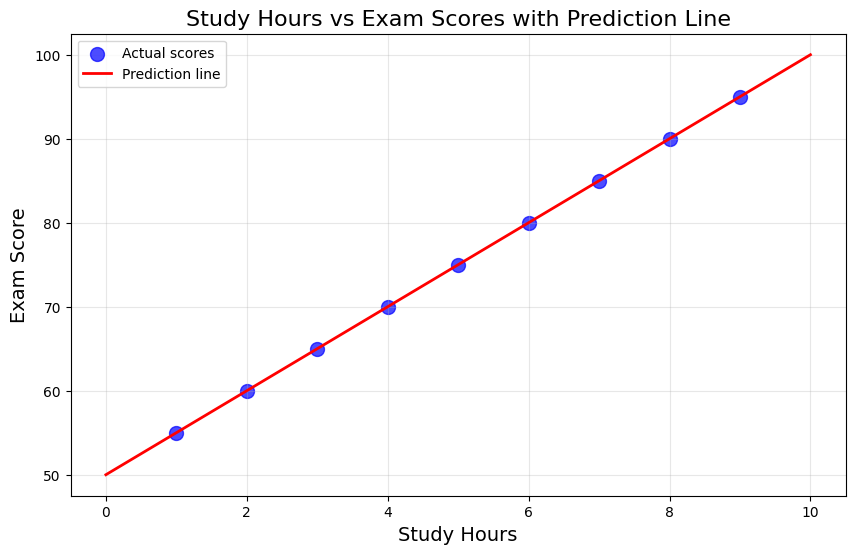

In [ ]:
# Visualize the model
plt.figure(figsize=(10, 6))

# Plot actual data points
plt.scatter(study_hours, exam_scores, color='blue', alpha=0.7, s=100, label='Actual scores')

# Plot regression line
x_range = np.linspace(0, 10, 100).reshape(-1, 1)
y_pred = model.predict(x_range)
plt.plot(x_range, y_pred, color='red', linewidth=2, label='Prediction line')

plt.title('Study Hours vs Exam Scores with Prediction Line', fontsize=16)
plt.xlabel('Study Hours', fontsize=14)
plt.ylabel('Exam Score', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Part 4: Testing Our Prediction Function

Let's test our prediction function with different study hour values.

In [ ]:
# Test with various study hours
test_hours = [2.5, 5.5, 10, 0, 12]

for hours in test_hours:
    predicted = predict_score(hours, model)
    print(f"Predicted score for {hours} study hours: {predicted}")

Predicted score for 2.5 study hours: 62
Predicted score for 5.5 study hours: 78
Predicted score for 10 study hours: 100
Predicted score for 0 study hours: 50
Predicted score for 12 study hours: 100


## Conclusion

In this notebook, we've learned how to:
1. Calculate important statistical measures from a dataset
2. Use various Python modules for data analysis and visualization
3. Create a model to predict outcomes based on our data

This demonstrates the fundamentals of working with small datasets, understanding their statistical properties, and building simple predictive models.